In [ ]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv('data/WTP_raw_data.csv')

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Influent Data,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Chemical Addition,Unnamed: 21,Unnamed: 22,Unnamed: 23,Filter,Unnamed: 25,Unnamed: 26,Unnamed: 27,Treated Water,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,Year,Month,Day,Date,[Raw] Flow [m3/d],[Raw] Alkalinity as CaCO3 [mg/L],[Raw] Max Tubidity [NTU],[Raw] Min Tubidity [NTU],[Raw] Mean Tubidity [NTU],[Raw] E.Coli [cfu/100mL],[Raw] TC [cfu/100mL],[Raw] Temperature [°C],[Raw] DOC [mg/L],[Raw] TOC [mg/L],[Raw] pH [-],[Raw] TAN [mg/L],[Raw] NO3-N [mg/L],[Raw] NO2-N [mg/L],[Raw] MIB [ng/L],[Raw] Geosmin [ng/L],[Chem] Powdered Activated Carbon Dose [mg/L],[Chem] Alum Dose [mg/L],[Chem] Polyaluminum Chloride Dose [mg/L],[Chem] Polymer Dosage [mg/L],[Filt] Max Turbidity [NTU],[Filt] Mean Turbidity [NTU],[Filt] Total Runtime [h],[Filt] Backwash Volume [m3],[TW] Flow [m3/d],[TW] Alkalinity as CaCO3 [mg/L],[TW] Cl Dosage [mg/L],[TW] pH [-],[TW] Al [mg/L],[TW] Turbidity [NTU],[TW] HAA [ug/L],[TW] THM [ug/L],[TW] TAN [mg/L],[TW] NO3-N [mg/L],[TW] NO2-N [mg/L],[TW] E. Coli [cfu/100mL],[TW] MIB [ug/L],[TW] Geosmin [ug/L]
1,2006,Jan,Sun,1/1/2006,NaN,110,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,0.87,27.74,NaN,0.1,0.11,0.06,51,882,21648,95,3.98,7.36,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Jan,Mon,1/2/2006,NaN,105,NaN,NaN,NaN,NaN,NaN,3.5,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,0.85,27.45,NaN,0.1,0.12,0.06,51,991,24489,85,3.33,7.34,0.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,Jan,Tue,1/3/2006,NaN,100,NaN,NaN,NaN,56,2,3,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,0.92,26.42,NaN,0.09,0.17,0.06,51,891,33095,85,3.84,7.29,0.008,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,2006,Jan,Wed,1/4/2006,NaN,100,NaN,NaN,NaN,NaN,NaN,4.5,NaN,NaN,8.02,0.2,0.43,0,NaN,NaN,0.85,25.27,NaN,0.09,0.1,0.07,48,1132,32277,85,3.51,7.3,0.02,NaN,NaN,NaN,0.4,0.42,0,NaN,NaN,NaN


In [5]:
df.columns = df.iloc[0]
df = df.iloc[1:, :96]
df.reset_index(drop=True, inplace=True)
df.head()

,Year,Month,Day,Date,[Raw] Flow [m3/d],[Raw] Alkalinity as CaCO3 [mg/L],[Raw] Max Tubidity [NTU],[Raw] Min Tubidity [NTU],[Raw] Mean Tubidity [NTU],[Raw] E.Coli [cfu/100mL],[Raw] TC [cfu/100mL],[Raw] Temperature [°C],[Raw] DOC [mg/L],[Raw] TOC [mg/L],[Raw] pH [-],[Raw] TAN [mg/L],[Raw] NO3-N [mg/L],[Raw] NO2-N [mg/L],[Raw] MIB [ng/L],[Raw] Geosmin [ng/L],[Chem] Powdered Activated Carbon Dose [mg/L],[Chem] Alum Dose [mg/L],[Chem] Polyaluminum Chloride Dose [mg/L],[Chem] Polymer Dosage [mg/L],[Filt] Max Turbidity [NTU],[Filt] Mean Turbidity [NTU],[Filt] Total Runtime [h],[Filt] Backwash Volume [m3],[TW] Flow [m3/d],[TW] Alkalinity as CaCO3 [mg/L],[TW] Cl Dosage [mg/L],[TW] pH [-],[TW] Al [mg/L],[TW] Turbidity [NTU],[TW] HAA [ug/L],[TW] THM [ug/L],[TW] TAN [mg/L],[TW] NO3-N [mg/L],[TW] NO2-N [mg/L],[TW] E. Coli [cfu/100mL],[TW] MIB [ug/L],[TW] Geosmin [ug/L]
0,2006,Jan,Sun,1/1/2006,NaN,110,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,0.87,27.74,NaN,0.1,0.11,0.06,51,882,21648,95,3.98,7.36,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,Jan,Mon,1/2/2006,NaN,105,NaN,NaN,NaN,NaN,NaN,3.5,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,0.85,27.45,NaN,0.1,0.12,0.06,51,991,24489,85,3.33,7.34,0.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Jan,Tue,1/3/2006,NaN,100,NaN,NaN,NaN,56,2,3,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,0.92,26.42,NaN,0.09,0.17,0.06,51,891,33095,85,3.84,7.29,0.008,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,2006,Jan,Wed,1/4/2006,NaN,100,NaN,NaN,NaN,NaN,NaN,4.5,NaN,NaN,8.02,0.2,0.43,0,NaN,NaN,0.85,25.27,NaN,0.09,0.1,0.07,48,1132,32277,85,3.51,7.3,0.02,NaN,NaN,NaN,0.4,0.42,0,NaN,NaN,NaN
4,2006,Jan,Thu,1/5/2006,NaN,105,NaN,NaN,NaN,NaN,NaN,4.3,NaN,NaN,8.01,NaN,NaN,NaN,NaN,NaN,1.28,27.41,NaN,0.08,2.04,0.11,48,2164,33540,90,3.66,7.28,0.019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 42 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Year                                          7305 non-null   object
 1   Month                                         7305 non-null   object
 2   Day                                           7305 non-null   object
 3   Date                                          7305 non-null   object
 4   [Raw] Flow [m3/d]                             3947 non-null   object
 5   [Raw] Alkalinity as CaCO3 [mg/L]              3819 non-null   object
 6   [Raw] Max Tubidity [NTU]                      4018 non-null   object
 7   [Raw] Min Tubidity [NTU]                      4018 non-null   object
 8   [Raw] Mean Tubidity [NTU]                     4018 non-null   object
 9   [Raw] E.Coli [cfu/100mL]                      1038 non-null   object
 10  

In [7]:
df.describe()

,Year,Month,Day,Date,[Raw] Flow [m3/d],[Raw] Alkalinity as CaCO3 [mg/L],[Raw] Max Tubidity [NTU],[Raw] Min Tubidity [NTU],[Raw] Mean Tubidity [NTU],[Raw] E.Coli [cfu/100mL],[Raw] TC [cfu/100mL],[Raw] Temperature [°C],[Raw] DOC [mg/L],[Raw] TOC [mg/L],[Raw] pH [-],[Raw] TAN [mg/L],[Raw] NO3-N [mg/L],[Raw] NO2-N [mg/L],[Raw] MIB [ng/L],[Raw] Geosmin [ng/L],[Chem] Powdered Activated Carbon Dose [mg/L],[Chem] Alum Dose [mg/L],[Chem] Polyaluminum Chloride Dose [mg/L],[Chem] Polymer Dosage [mg/L],[Filt] Max Turbidity [NTU],[Filt] Mean Turbidity [NTU],[Filt] Total Runtime [h],[Filt] Backwash Volume [m3],[TW] Flow [m3/d],[TW] Alkalinity as CaCO3 [mg/L],[TW] Cl Dosage [mg/L],[TW] pH [-],[TW] Al [mg/L],[TW] Turbidity [NTU],[TW] HAA [ug/L],[TW] THM [ug/L],[TW] TAN [mg/L],[TW] NO3-N [mg/L],[TW] NO2-N [mg/L],[TW] E. Coli [cfu/100mL],[TW] MIB [ug/L],[TW] Geosmin [ug/L]
count,7305,7305,7305,7305,3947,3819,4018,4018,4018,1038,1038,7259,338,338,7291,626,634,634,226,226,7199,3433,1618,7015,7284,7279,7223,7249,7295,3827,7295,7300,7293,2626,34,82,601,627,627,1047,229,229
unique,20,12,7,7305,3813,62,747,523,1096,40,146,1628,15,15,191,49,97,6,5,16,356,1818,1080,33,140,34,703,2726,6549,53,362,136,318,37,7,59,64,98,5,3,5,11
top,2008,Jan,Sun,1/1/2006,57116,110,4.8,2.4,3.1,2,10,0.5,2,2,8.01,0.04,0.5,0,3,3,3,0,24.73,0.1,0.12,0.04,0,0,48642,90,3.1,7.26,0.016,0.02,5.3,22,0.28,0.5,0,0,3,3
freq,366,620,1044,1,3,587,51,109,62,466,65,163,249,262,117,141,52,306,214,165,836,69,7,887,421,1642,242,180,5,895,66,191,179,522,28,3,30,52,373,1045,220,200


params:
tubidity (723 datapts, 453 unique)
ph (2922 datapts, 163 unique)

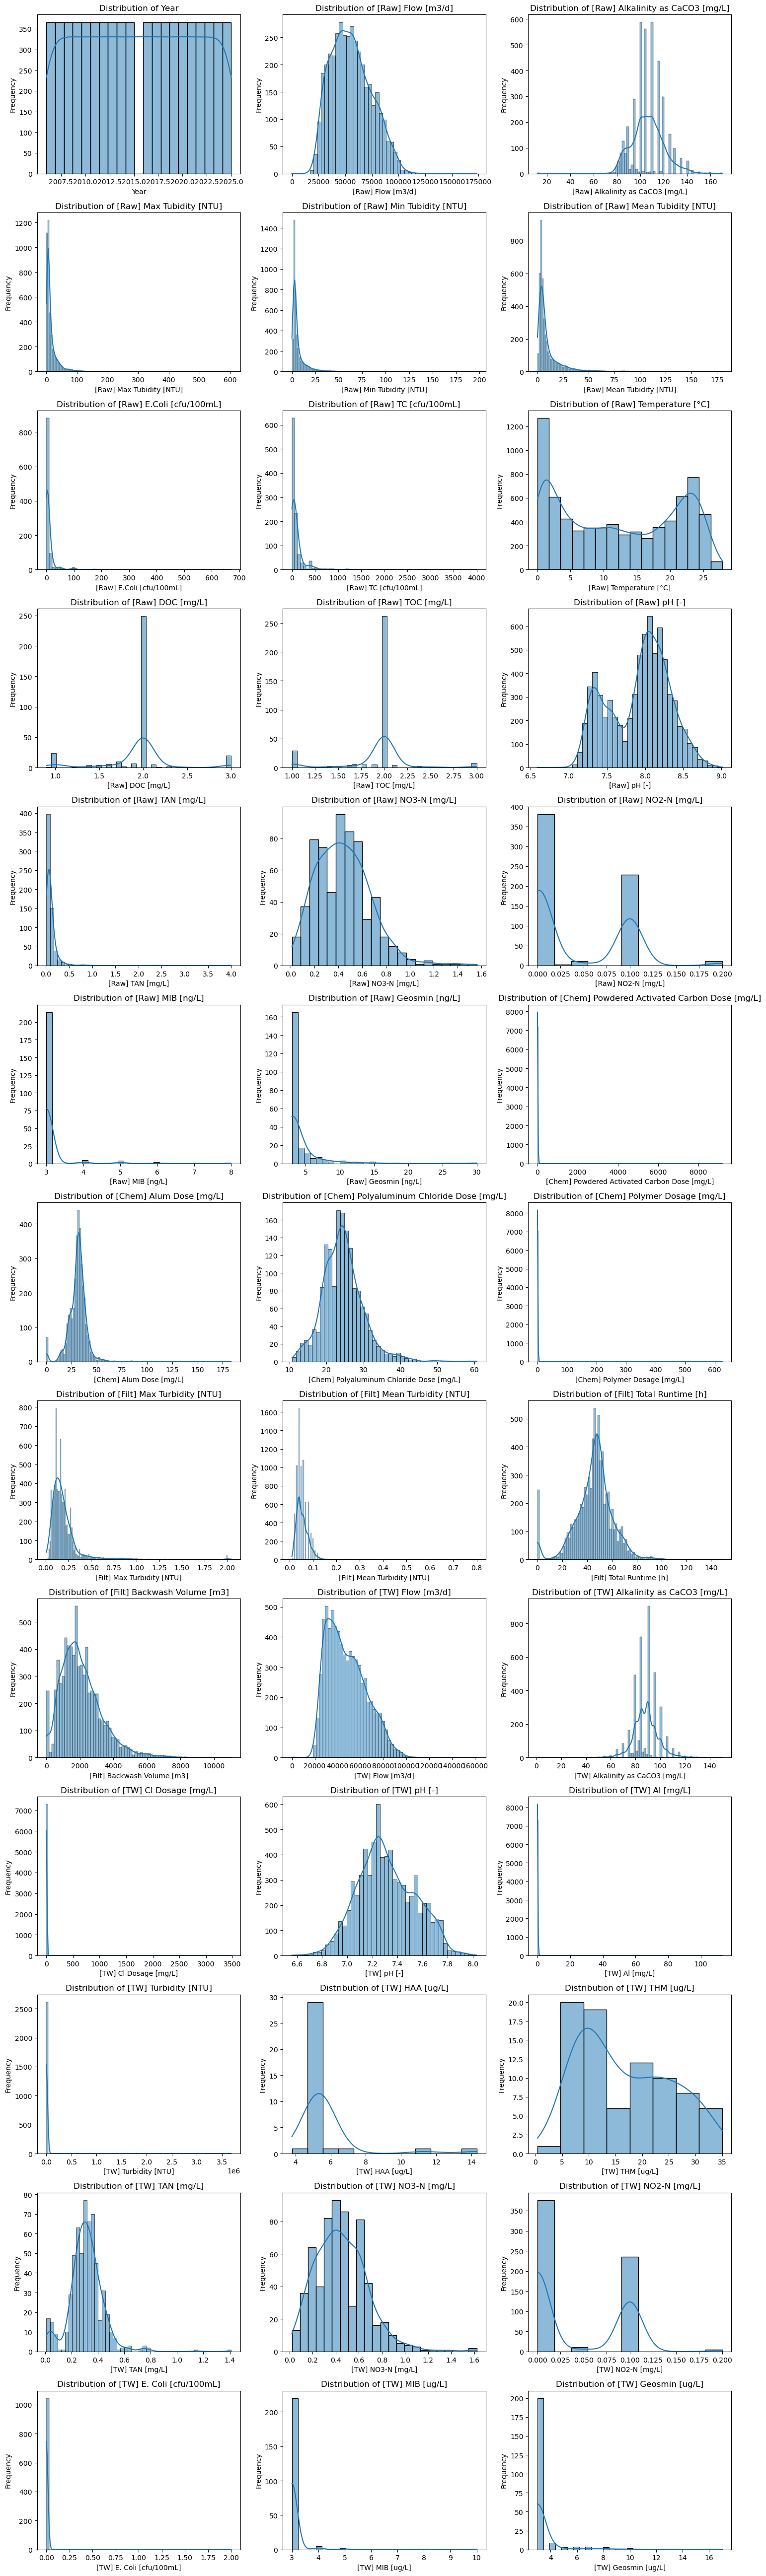

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Convert columns to numeric, coercing errors to NaN to handle non-numeric values
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Drop columns that are completely empty or all NaN
df_numeric = df_numeric.dropna(axis=1, how='all')

# Set up the subplot grid
num_plots = len(df_numeric.columns)
cols = 3  # Number of plots per row
rows = math.ceil(num_plots / cols)

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Iterate through each numeric column and plot
for i, col in enumerate(df_numeric.columns):
    sns.histplot(df_numeric[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

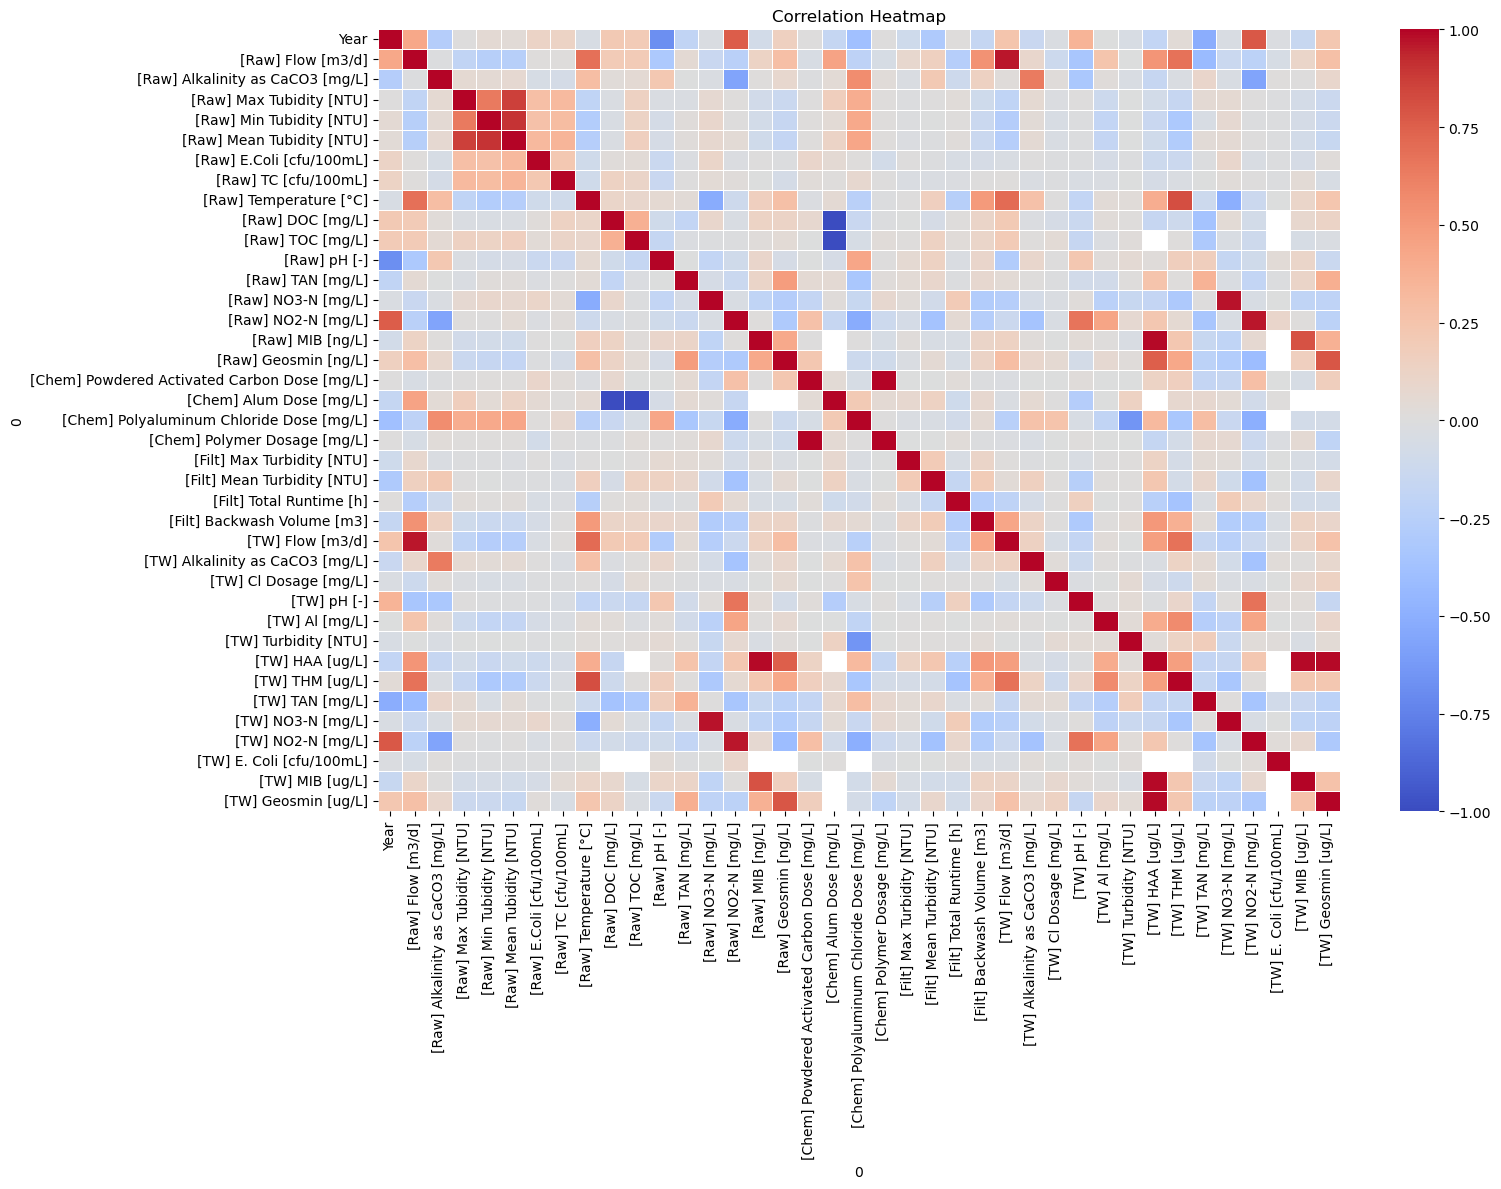

In [9]:
corr = df_numeric.corr() #pearson
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
# Get the top 10 correlated features (excluding self-correlation)
corr_unstacked = corr.unstack()
corr_unstacked = corr_unstacked.drop(labels=[(i, i) for i in corr.columns])
top_10_corr = corr_unstacked.abs().nlargest(10)

print("Top 10 Correlated Feature Pairs:")
print(top_10_corr)
print("\nDetails:")
for (col1, col2), value in top_10_corr.items():
    print(f"{col1} <-> {col2}: {value:.4f}")

Top 10 Correlated Feature Pairs:
0                                             0                                           
[Raw] DOC [mg/L]                              [Chem] Alum Dose [mg/L]                         1.000000
[Chem] Alum Dose [mg/L]                       [Raw] DOC [mg/L]                                1.000000
[Raw] TOC [mg/L]                              [Chem] Alum Dose [mg/L]                         1.000000
[Chem] Alum Dose [mg/L]                       [Raw] TOC [mg/L]                                1.000000
[Chem] Powdered Activated Carbon Dose [mg/L]  [Chem] Polymer Dosage [mg/L]                    0.998843
[Chem] Polymer Dosage [mg/L]                  [Chem] Powdered Activated Carbon Dose [mg/L]    0.998843
[Raw] MIB [ng/L]                              [TW] HAA [ug/L]                                 0.990851
[TW] HAA [ug/L]                               [Raw] MIB [ng/L]                                0.990851
                                              [TW] M

Histogram/Distributions by Month, for each variable

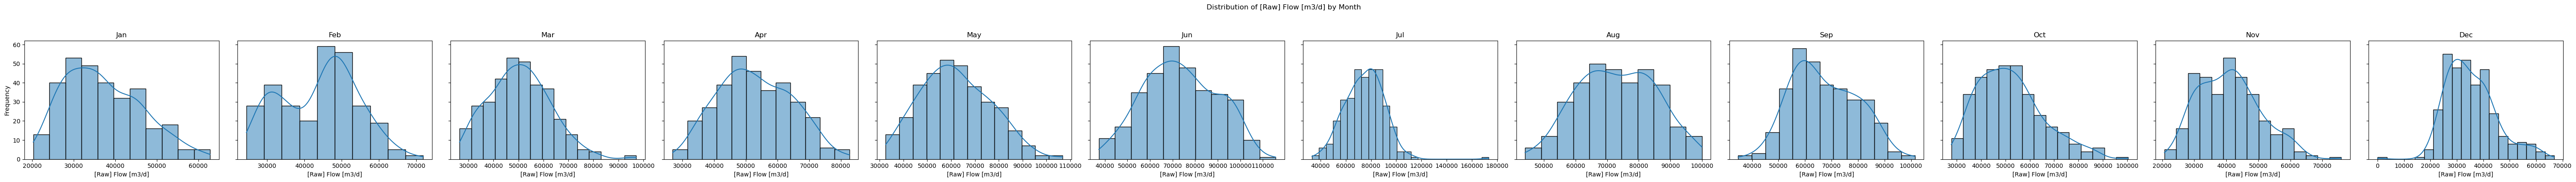

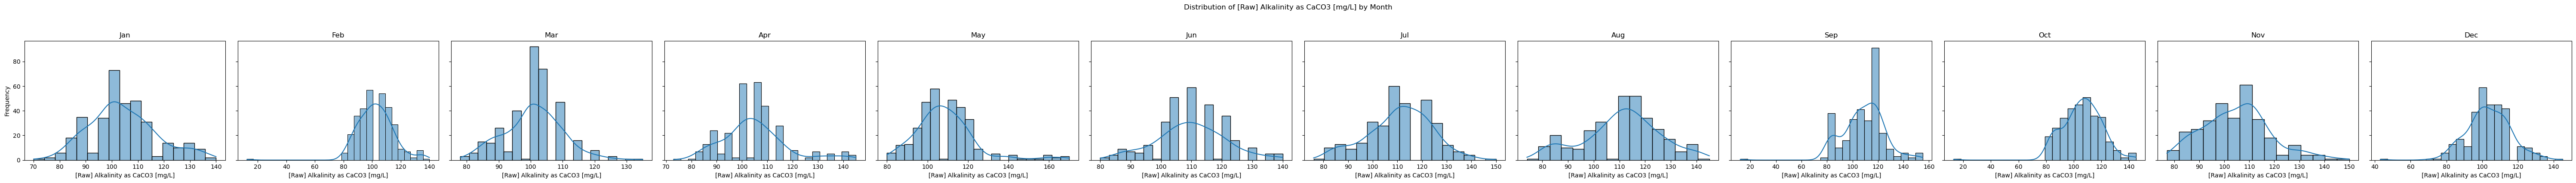

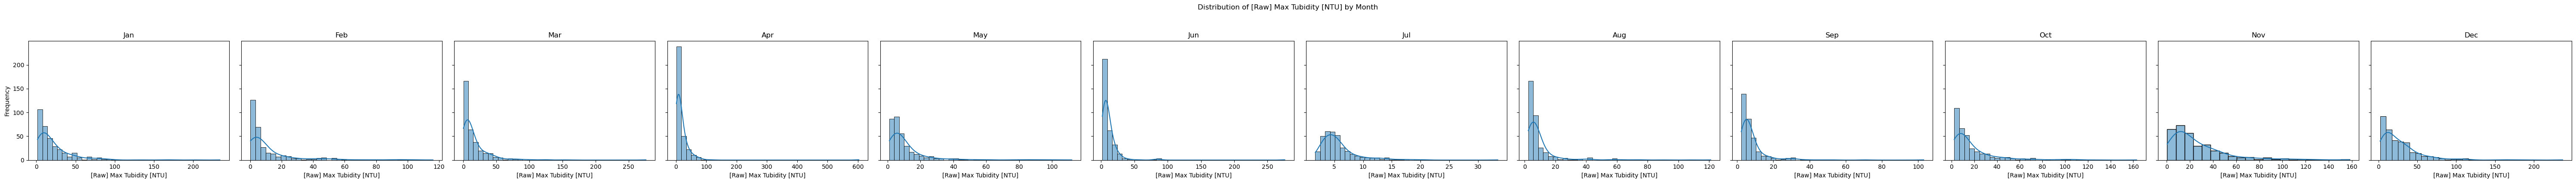

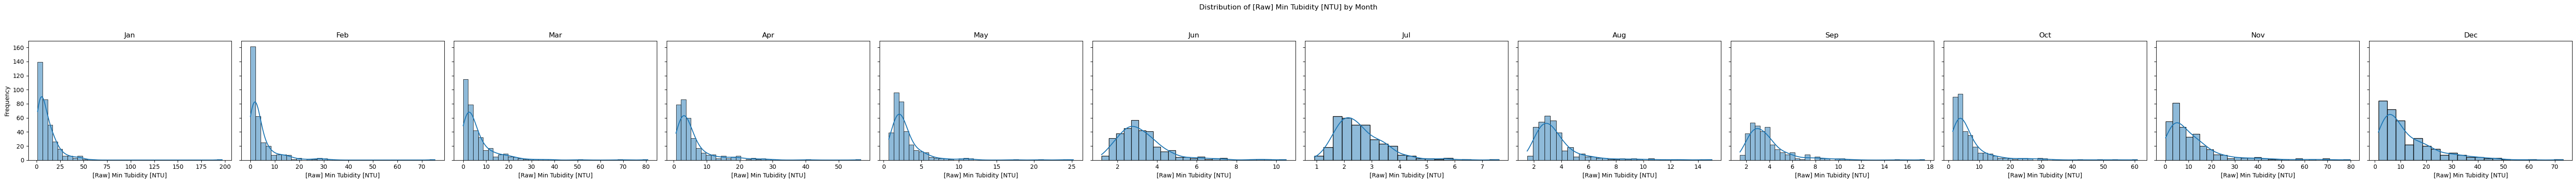

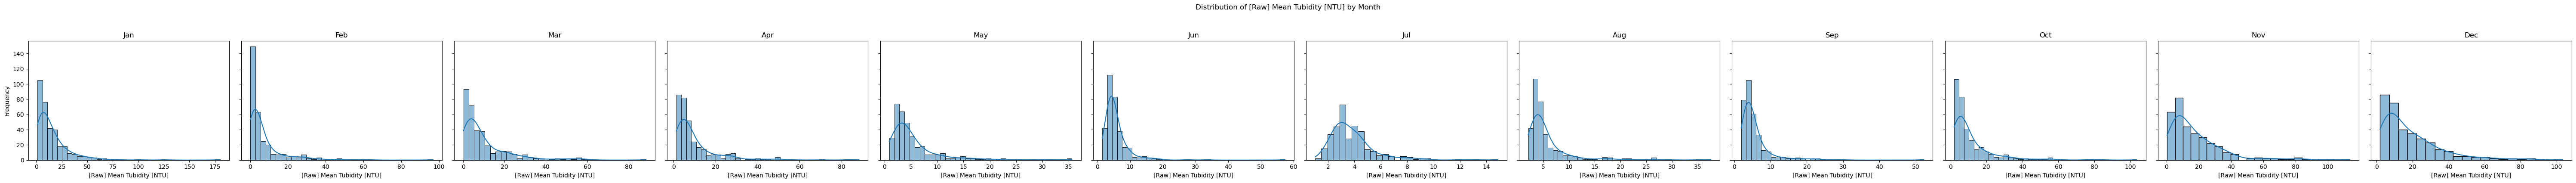

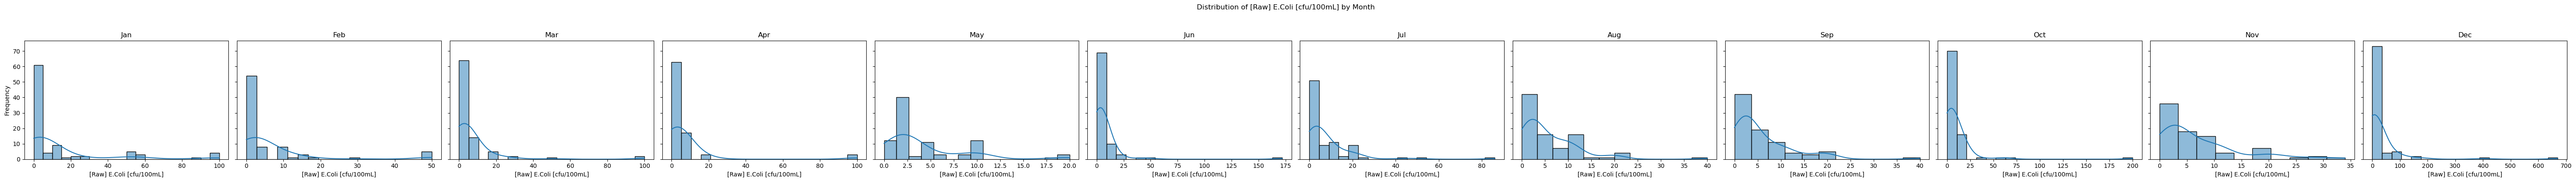

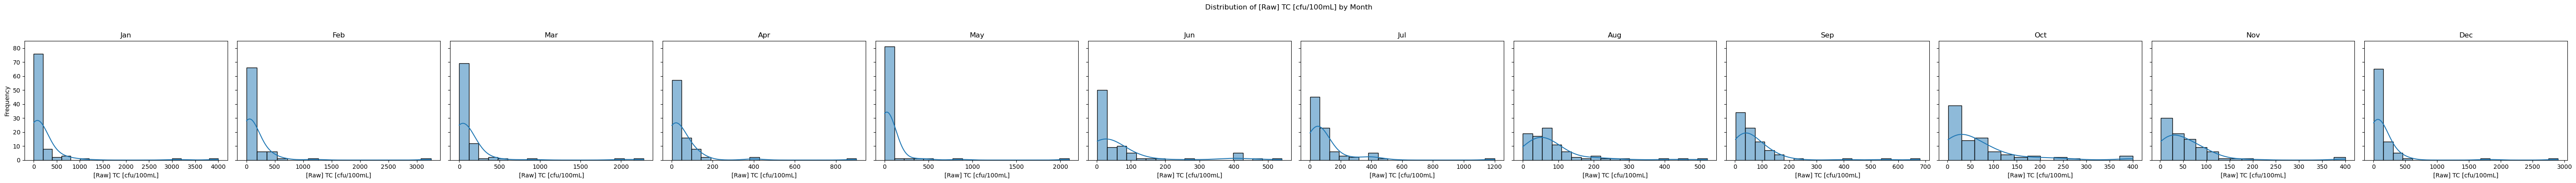

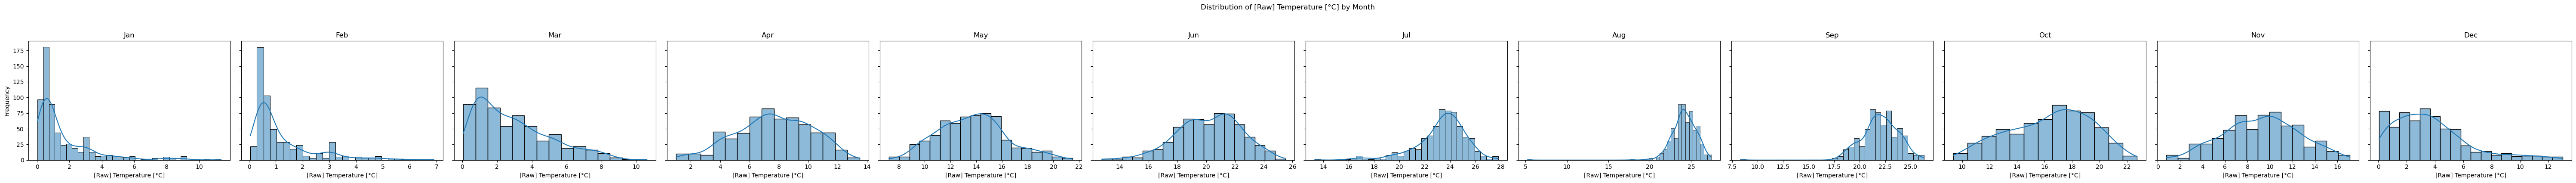

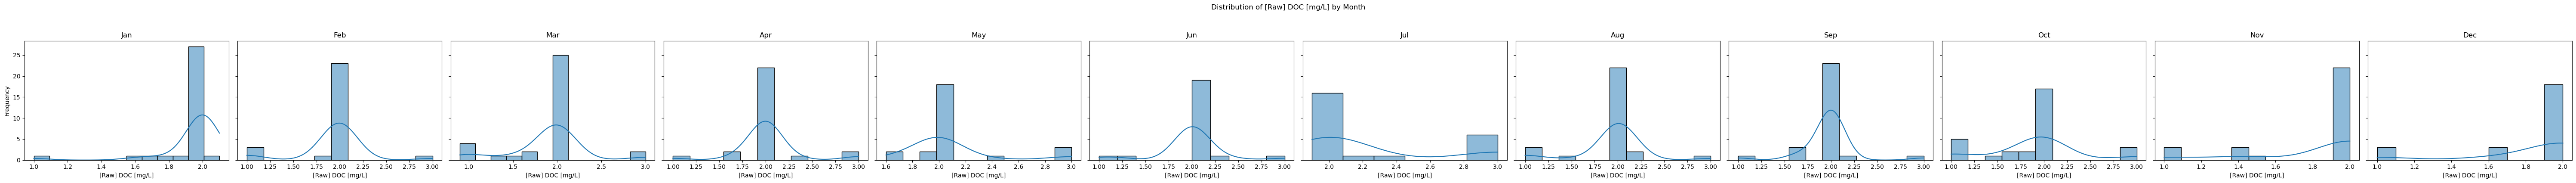

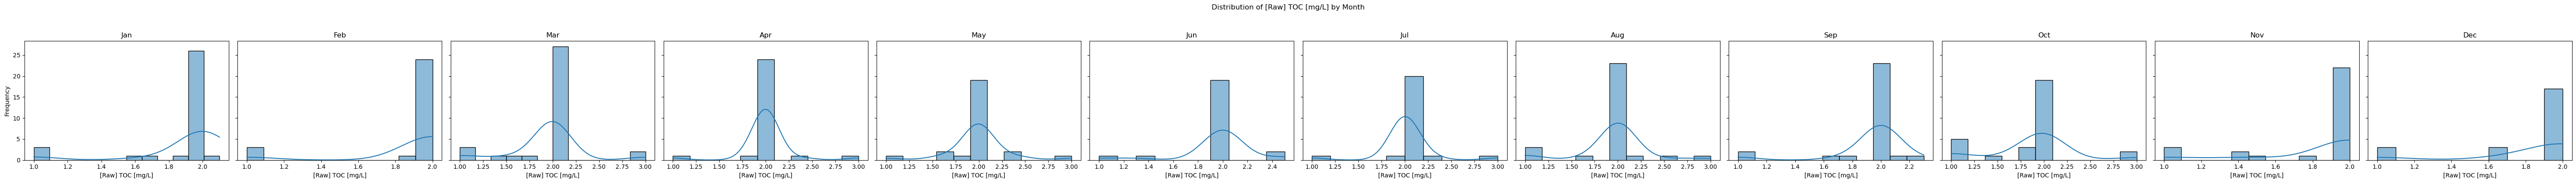

KeyboardInterrupt: 

In [11]:
df_plot = df.copy()
df_plot["Month"] = df_plot["Month"].astype(str)

# numeric columns (excluding non-numeric and Month)
numeric_cols = df_plot.columns.drop(["Year", "Month", "Day", "Date"])
df_plot[numeric_cols] = df_plot[numeric_cols].apply(pd.to_numeric, errors="coerce")

months = df_plot["Month"].dropna().unique()

for col in numeric_cols:
    num_months = len(months)
    # Create one row of subplots for the months
    fig, axes = plt.subplots(1, num_months, figsize=(5 * num_months, 4), sharey=True)
    
    # Ensure axes is iterable if there's only one month
    if num_months == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for i, month in enumerate(months):
        subset = df_plot[df_plot["Month"] == month]
        sns.histplot(subset[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"{month}")
        axes[i].set_xlabel(col)
        if i == 0:
            axes[i].set_ylabel("Frequency")
        else:
            axes[i].set_ylabel("") # Hide y-label for shared axes

    plt.suptitle(f"Distribution of {col} by Month", y=1.05)
    plt.tight_layout()
    plt.show()

Histograms by year

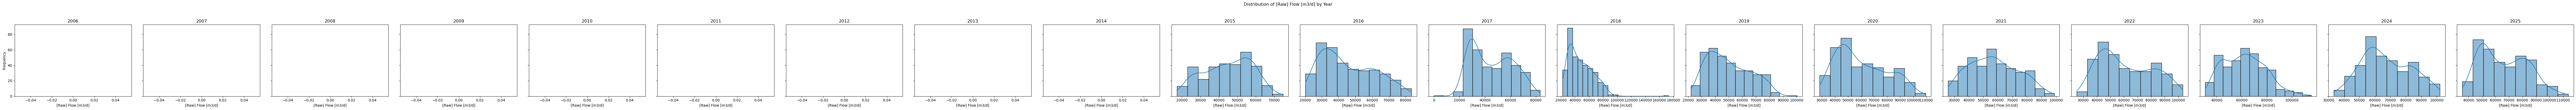

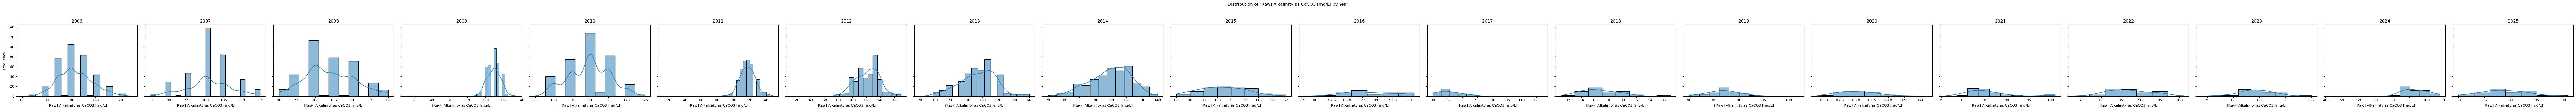

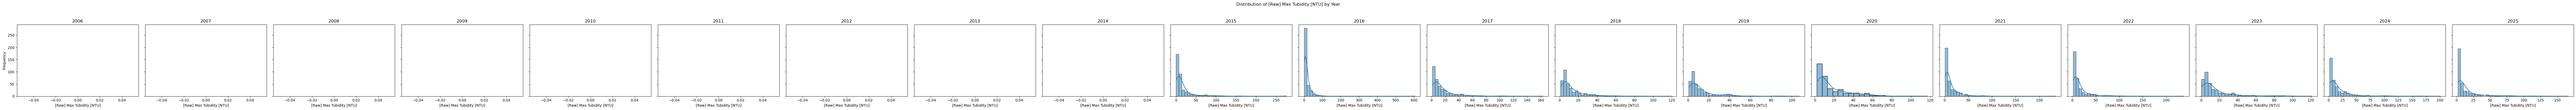

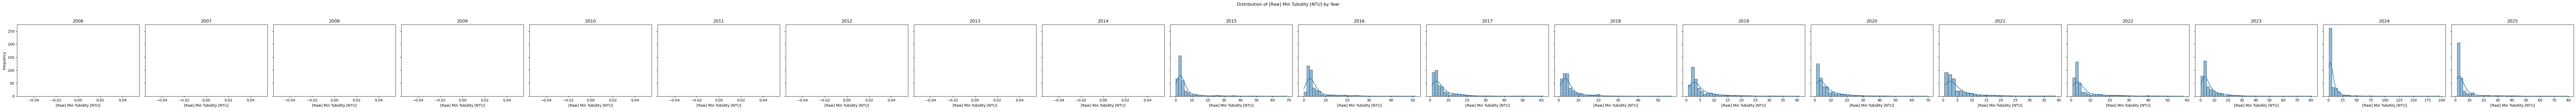

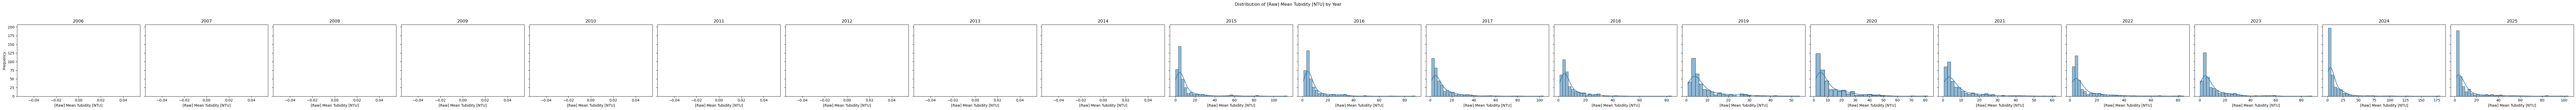

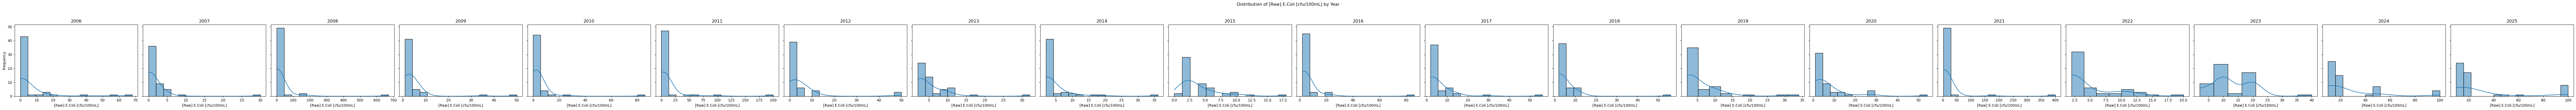

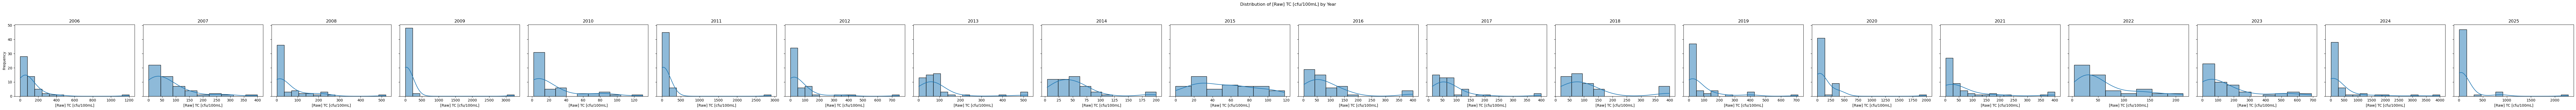

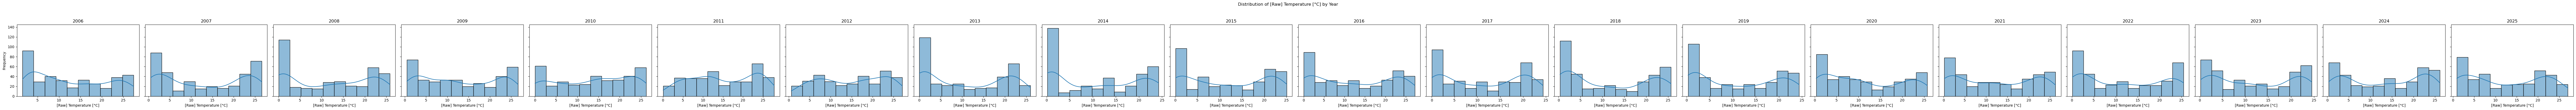

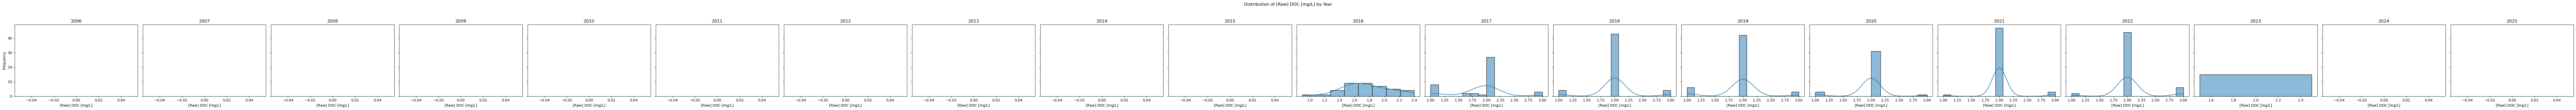

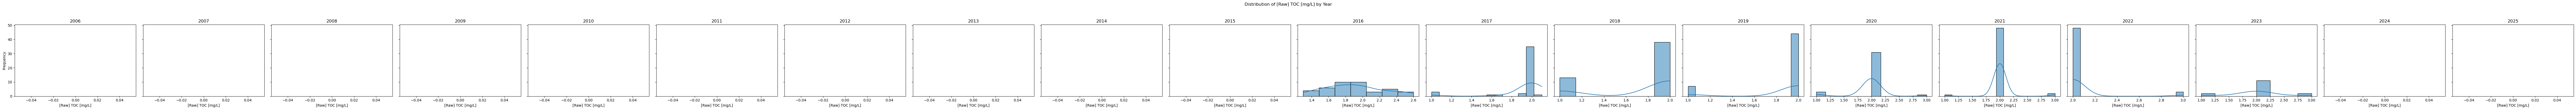

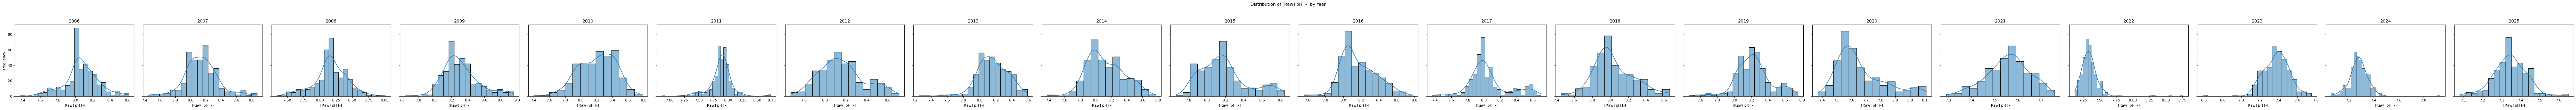

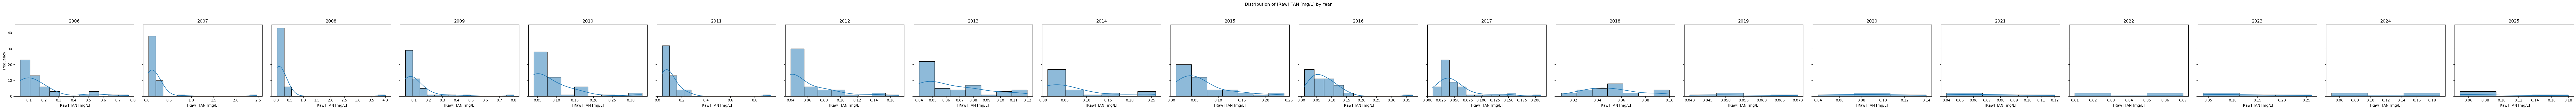

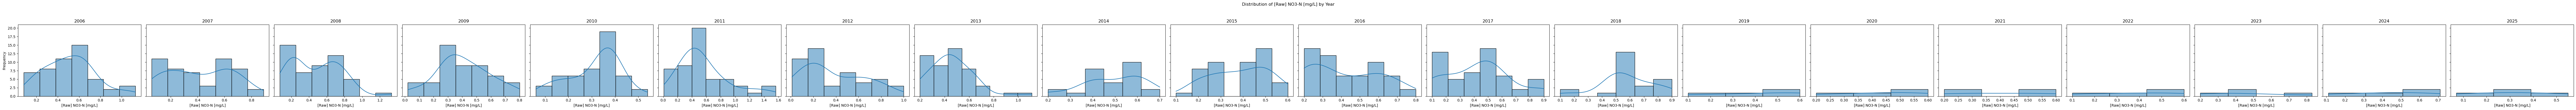

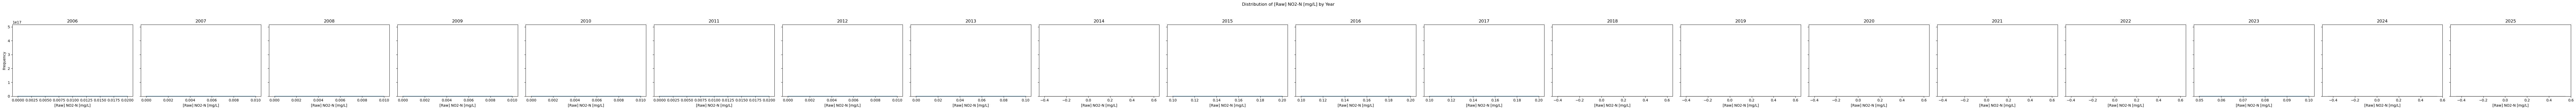

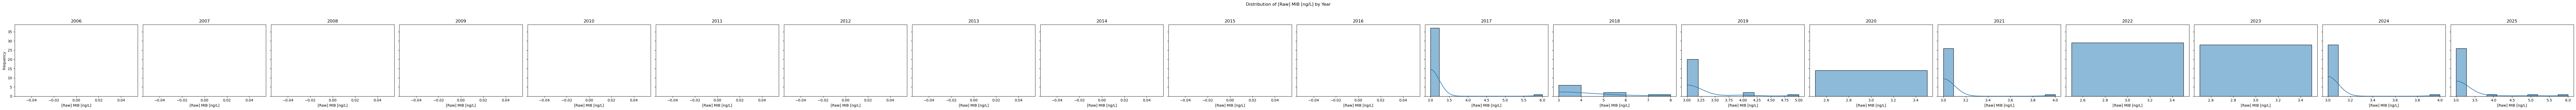

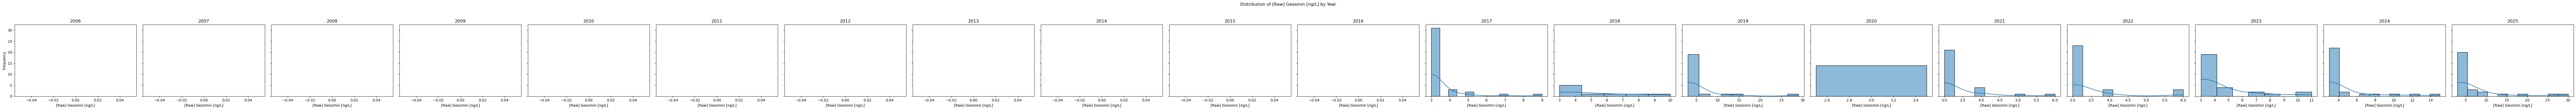

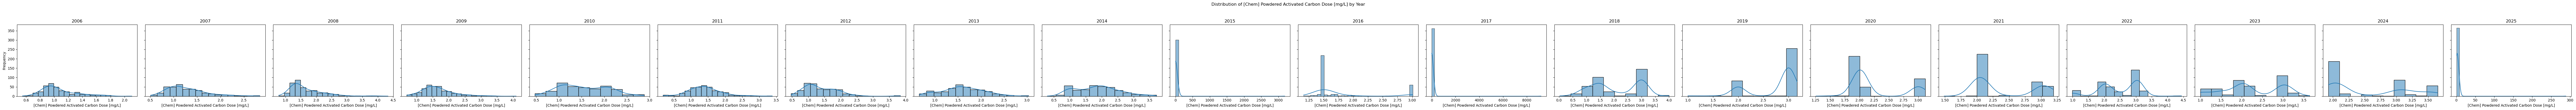

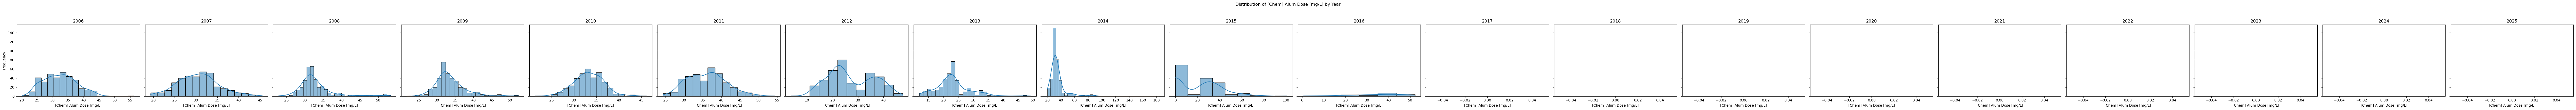

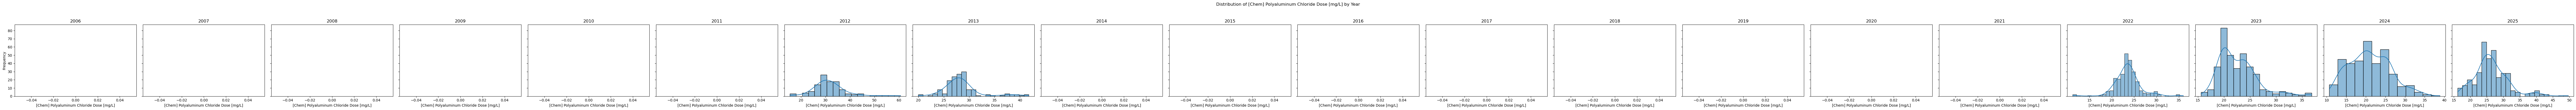

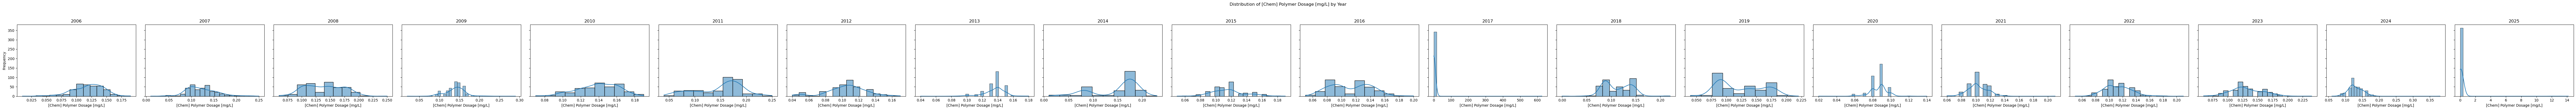

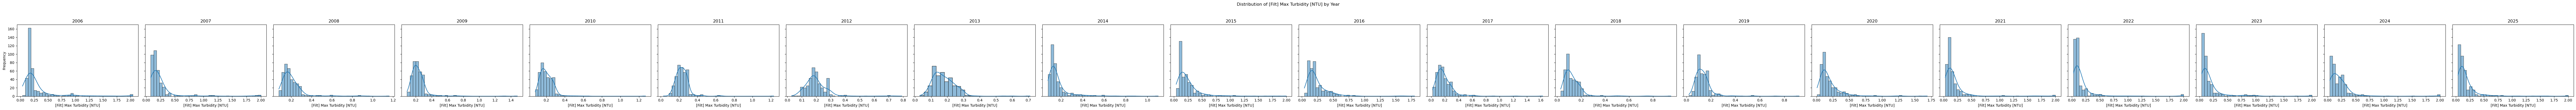

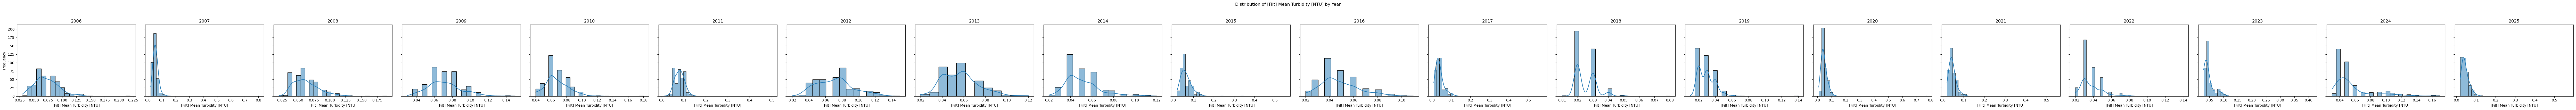

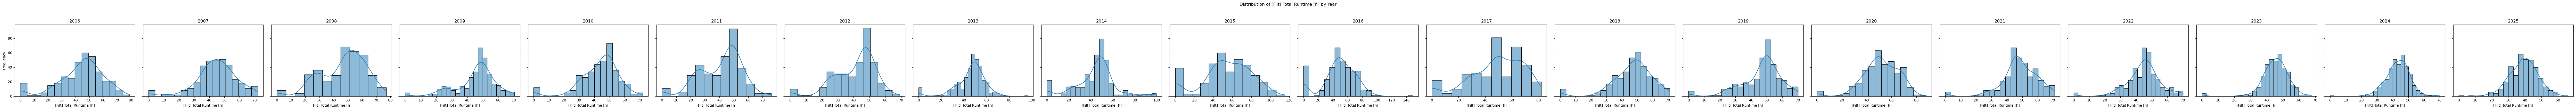

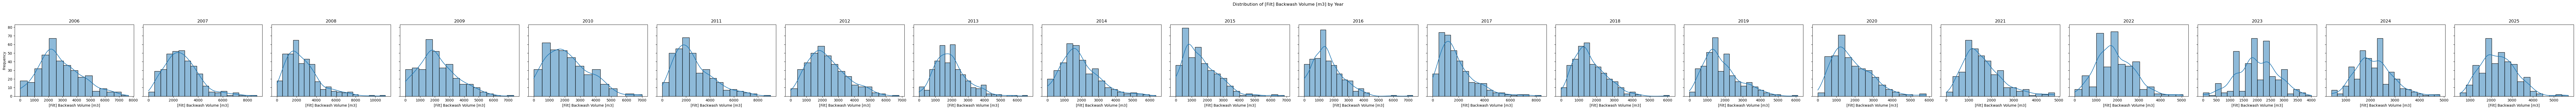

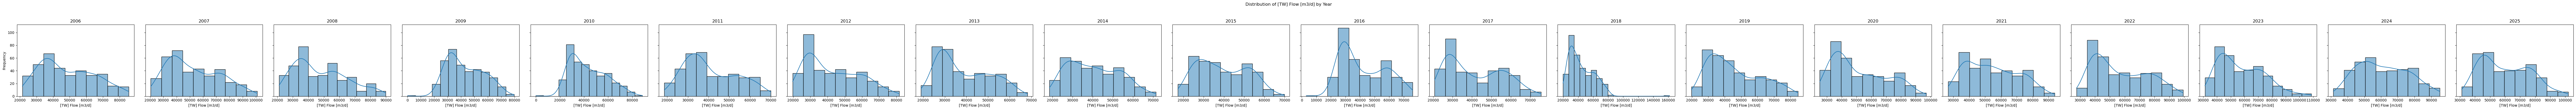

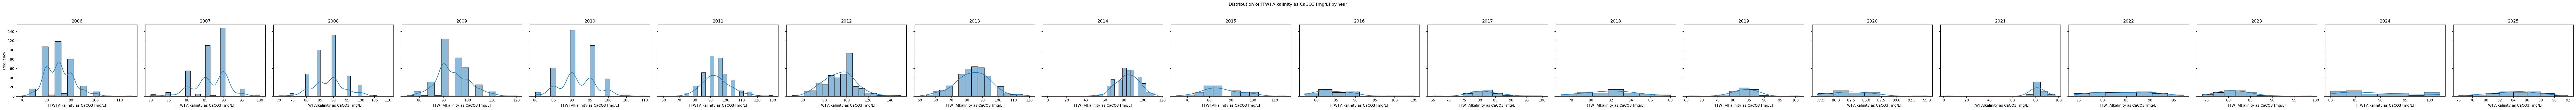

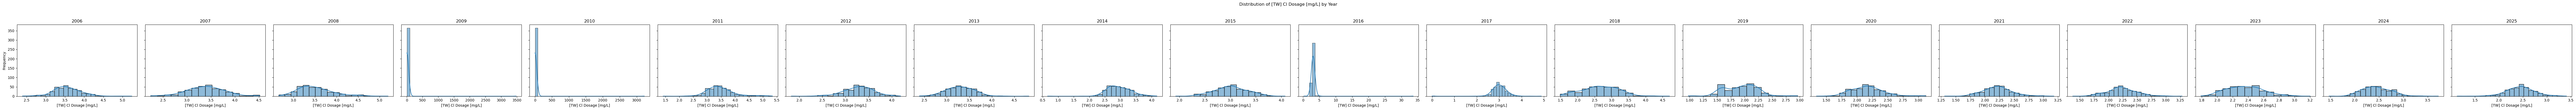

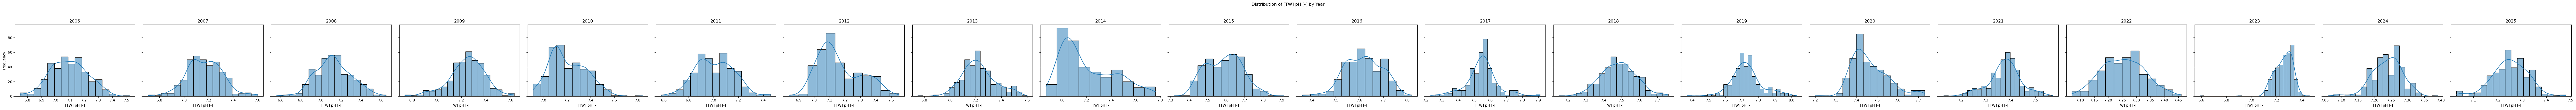

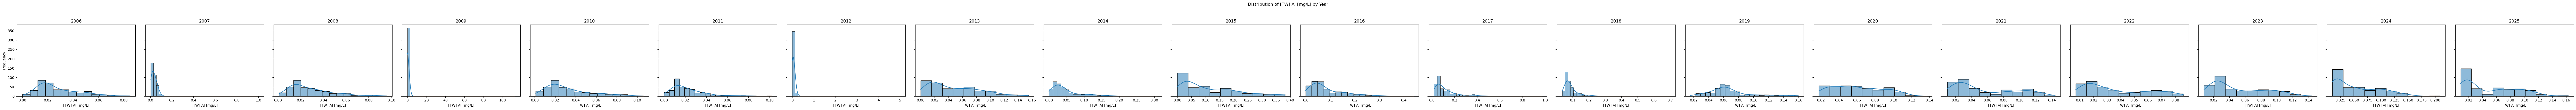

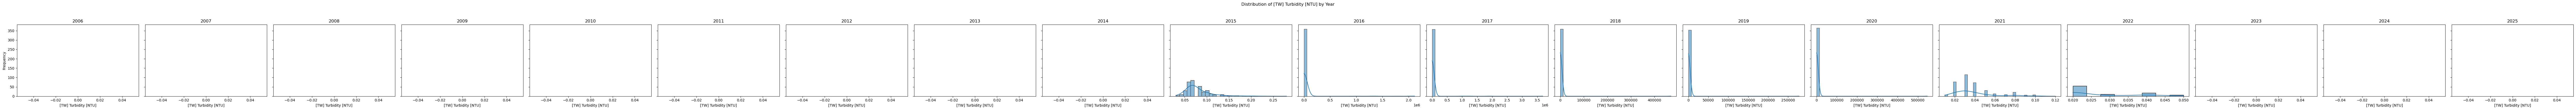

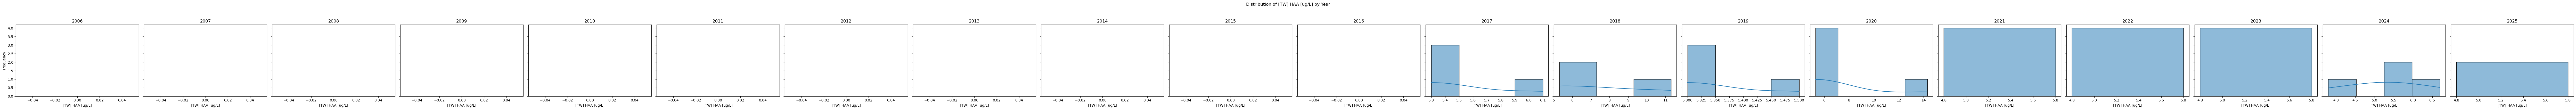

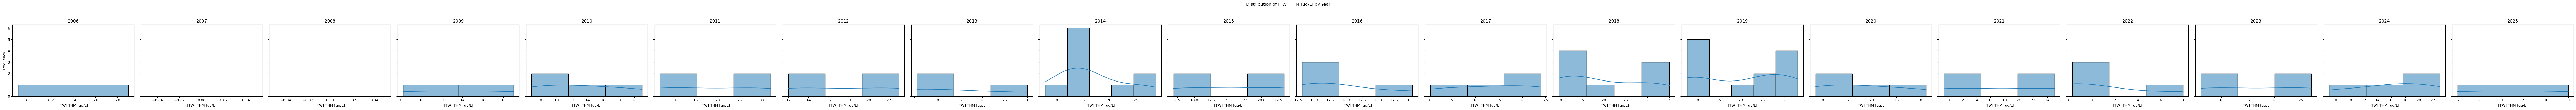

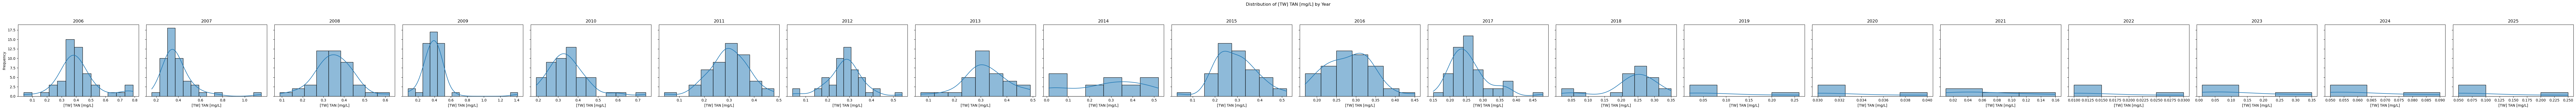

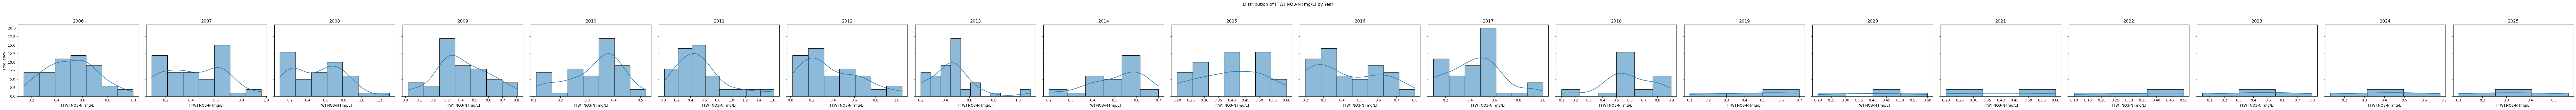

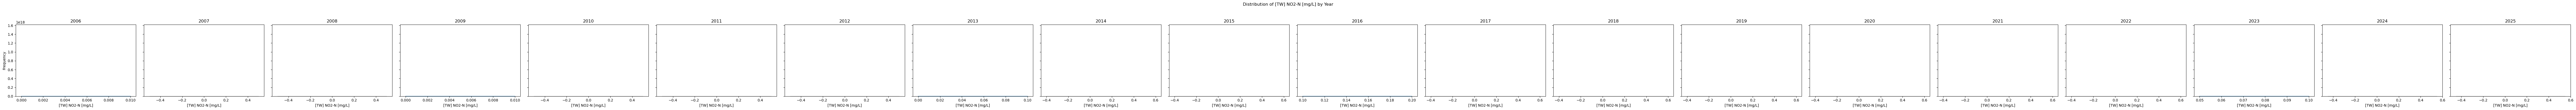

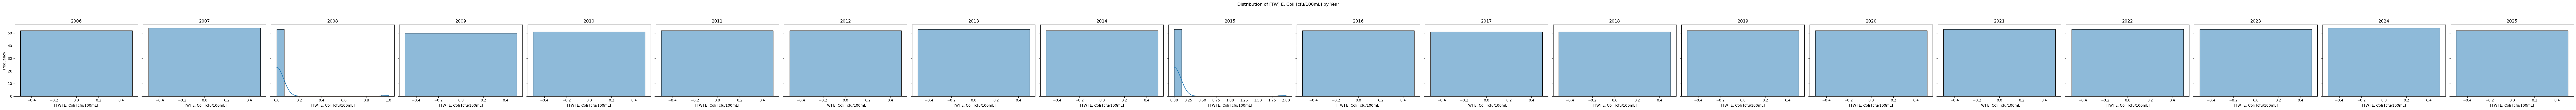

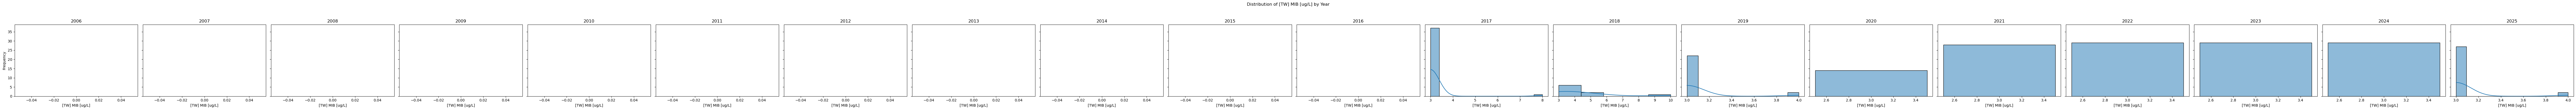

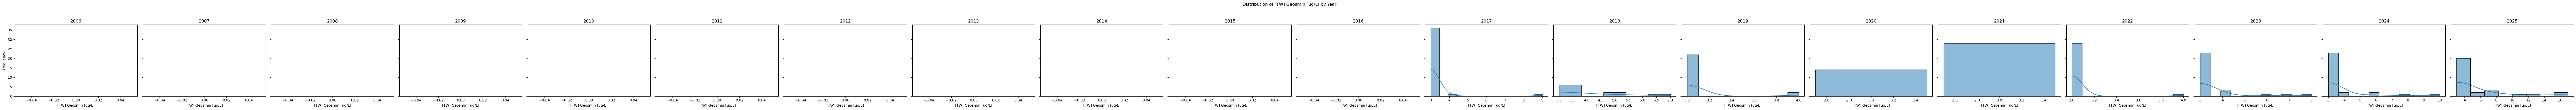

In [ ]:
# Use existing df_plot and numeric_cols from previous cell
df_plot["Year"] = df_plot["Year"].astype(str)
years = df_plot["Year"].dropna().unique()

for col in numeric_cols:
    num_years = len(years)
    fig, axes = plt.subplots(1, num_years, figsize=(5 * num_years, 4), sharey=True)

    if num_years == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for i, year in enumerate(years):
        subset = df_plot[df_plot["Year"] == year]
        sns.histplot(subset[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"{year}")
        axes[i].set_xlabel(col)
        if i == 0:
            axes[i].set_ylabel("Frequency")
        else:
            axes[i].set_ylabel("")

    plt.suptitle(f"Distribution of {col} by Year", y=1.05)
    plt.tight_layout()
    plt.show()

Check if turbidity on day x influences raw turbidity on succeeding days

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Create date index from df_plot
df_ts = df_plot.copy()
df_ts['Date'] = pd.to_datetime(df_ts['Date'])
df_ts = df_ts.sort_values('Date').set_index('Date')

# Convert target column to numeric
target_col = '[Raw] Mean Turbidity [NTU]'

# Check if column exists, if not print available columns
if target_col not in df_ts.columns:
	print("Available columns:")
	print(df_ts.columns.tolist())
	raise KeyError(f"Column '{target_col}' not found in dataframe")

# Ensure the column is numeric
df_ts[target_col] = pd.to_numeric(df_ts[target_col], errors='coerce')
series = df_ts[target_col].dropna()

# Verify we have data
if len(series) == 0:
	print(f"No valid data found for {target_col}")
	print(f"Column dtype: {df_ts[target_col].dtype}")
else:
	print(f"Successfully loaded {len(series)} data points for {target_col}")

# 2. Plot Autocorrelation
# ACF: Shows the cumulative correlation over time
# PACF: Shows the direct correlation (removing intermediate days)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot ACF (Total Memory)
plot_acf(series, lags=30, ax=ax1)
ax1.set_title(f'Autocorrelation (ACF): Total Effect of {target_col} over time')
ax1.set_xlabel('Lag (Days)')
ax1.set_ylabel('Correlation')

# Plot PACF (Direct Memory)
plot_pacf(series, lags=30, ax=ax2)
ax2.set_title(f'Partial Autocorrelation (PACF): Direct Effect of {target_col}')
ax2.set_xlabel('Lag (Days)')
ax2.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

Available columns:
['Year', 'Month', 'Day', '[Raw] Flow [m3/d]', '[Raw] Alkalinity as CaCO3 [mg/L]', '[Raw] Max Tubidity [NTU]', '[Raw] Min Tubidity [NTU]', '[Raw] Mean Tubidity [NTU]', '[Raw] E.Coli [cfu/100mL]', '[Raw] TC [cfu/100mL]', '[Raw] Temperature [°C]', '[Raw] DOC [mg/L]', '[Raw] TOC [mg/L]', '[Raw] pH [-]', '[Raw] TAN [mg/L]', '[Raw] NO3-N [mg/L]', '[Raw] NO2-N [mg/L]', '[Raw] MIB [ng/L]', '[Raw] Geosmin [ng/L]', '[Chem] Powdered Activated Carbon Dose [mg/L]', '[Chem] Alum Dose [mg/L]', '[Chem] Polyaluminum Chloride Dose [mg/L]', '[Chem] Polymer Dosage [mg/L]', '[Filt] Max Turbidity [NTU]', '[Filt] Mean Turbidity [NTU]', '[Filt] Total Runtime [h]', '[Filt] Backwash Volume [m3]', '[TW] Flow [m3/d]', '[TW] Alkalinity as CaCO3 [mg/L]', '[TW] Cl Dosage [mg/L]', '[TW] pH [-]', '[TW] Al [mg/L]', '[TW] Turbidity [NTU]', '[TW] HAA [ug/L]', '[TW] THM [ug/L]', '[TW] TAN [mg/L]', '[TW] NO3-N [mg/L]', '[TW] NO2-N [mg/L]', '[TW] E. Coli [cfu/100mL]', '[TW] MIB [ug/L]', '[TW] Geosmin [ug/

KeyError: "Column '[Raw] Mean Turbidity [NTU]' not found in dataframe"